In [52]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [60]:
df = pd.read_csv(r"D:\Projects\Synthetic Data Generation\applications\dataprivacy\dataset\HR_pre_processed_data.csv")
ep_0_1 = pd.read_csv("datasets/current_best_hr_gen_epsilon_0.1.csv").iloc[:,1:]
ep_0_3 = pd.read_csv("datasets/current_best_hr_gen_epsilon_0.3.csv").iloc[:,1:]
ep_0_5 = pd.read_csv("datasets/current_best_hr_gen_epsilon_0.5.csv").iloc[:,1:]
ep_0_7 = pd.read_csv("datasets/current_best_hr_gen_epsilon_0.7.csv").iloc[:,1:]
ep_1 = pd.read_csv("datasets/current_best_hr_gen_epsilon_1.csv").iloc[:,1:]

In [65]:
ep_0_1.head()

,Age,Department,Education,EducationField,Gender,JobLevel,MonthlyIncome,PercentSalaryHike,TotalWorkingYears,YearsAtCompany
0,38,0,3,1,1,1,1665,30,16,1
1,62,2,3,1,1,1,4175,30,7,0
2,52,0,2,1,1,2,2423,30,0,2
3,31,2,3,1,1,1,4591,30,1,1
4,31,2,3,1,1,2,3862,30,13,1


In [61]:
features = list(df.columns)
target_variable = "MonthlyIncome"
features.remove(target_variable)
print(features)

['Age', 'Department', 'Education', 'EducationField', 'Gender', 'JobLevel', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany']


In [62]:
x, y = df[features], df[target_variable]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 1/3, random_state=0)
regr = RandomForestRegressor(random_state=0, n_estimators=100)
regr.fit(X_train, y_train)
y_pred = regr.predict(X_test)
r_score = round(r2_score(y_test, y_pred), 3)
print("Original R2 Score:", r_score)

Original R2 Score: 0.915


In [63]:
def ml_ep(X_p, y_p, X_o, y_o):
    model = RandomForestRegressor(random_state=0, n_estimators=1000)
    model.fit(X_p, y_p)
    y_pred = regr.predict(X_p)
    print(round(r2_score(y_p, y_pred), 3))
    CV_scores = []
    start = 0
    for fold in range(1, 10):
        end = start + int(len(X_o) / 10)
        X_test_real = X_o.iloc[start:end]
        y_test_real = y_o[start:end]
        y_pred = model.predict(X_test_real)
        score = r2_score(y_test_real, y_pred)
        CV_scores.append(score)
        start = end
    return np.mean(CV_scores)

In [68]:
ep = ep_0_1.copy()
X_p, y_p = ep[features], ep[target_variable]
print(ml_ep(X_p, y_p, X_test, y_test))

-4.933
-0.3881635279139425


In [69]:
ep = ep_0_3.copy()
X_p, y_p = ep[features], ep[target_variable]
ml_ep(X_p, y_p, X_test, y_test)

-0.987


-1.905928802624337

In [70]:
ep = ep_0_5.copy()
X_p, y_p = ep[features], ep[target_variable]
ml_ep(X_p, y_p, X_test, y_test)

-1.751


-1.3924620376159649

In [71]:
ep = ep_0_7.copy()
X_p, y_p = ep[features], ep[target_variable]
ml_ep(X_p, y_p, X_test, y_test)

-58.757


-0.9913577536488012

In [72]:
ep = ep_1.copy()
X_p, y_p = ep[features], ep[target_variable]
ml_ep(X_p, y_p, X_test, y_test)

-9.031


-0.5987650534761961

<AxesSubplot:>

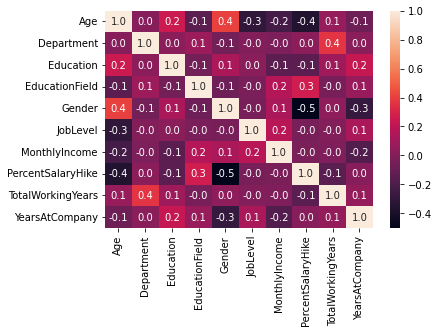

In [73]:
sns.heatmap(ep.corr(), annot=True, fmt="0.1f")

<AxesSubplot:>

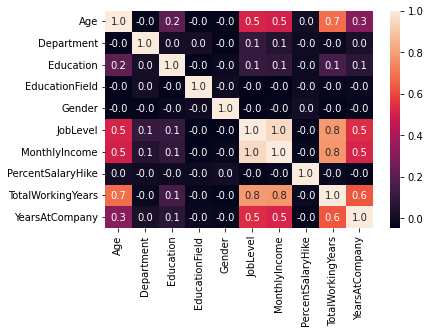

In [74]:
sns.heatmap(df.corr(), annot=True, fmt="0.1f")